In [1]:
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
effect_k_files = glob("../evaluation_results/1_5_effect_k/*.csv")

In [3]:
dfs = {csv.split("processed_")[1].split(".hdf5.csv")[0]: pd.read_csv(csv) for csv in effect_k_files}

In [4]:
df = pd.concat(dfs, axis=0).reset_index(names=["dataset", "drop"]).drop("drop", axis=1)

In [5]:
df["log(P)"] = np.log(df["P"])

/data/bionets/je30bery/conda/envs/xm/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
df["k"] = pd.Categorical(df["k"], ['10', '20', '50', '100', '500', '1000', '2000', 'full'])

array(['withdraw_15d_Cocaine', 'withdraw_48h_Cocaine', 'Idasanutlin_24',
       'Idasanutlin_6', 'Trametinib_24', 'Trametinib_6', 'BRD3379_24',
       'BRD3379_6'], dtype=object)

In [14]:
palette = {val: sns.color_palette("Paired", 8)[i] for i, val in enumerate(sorted(df["testgroup"].unique()))}

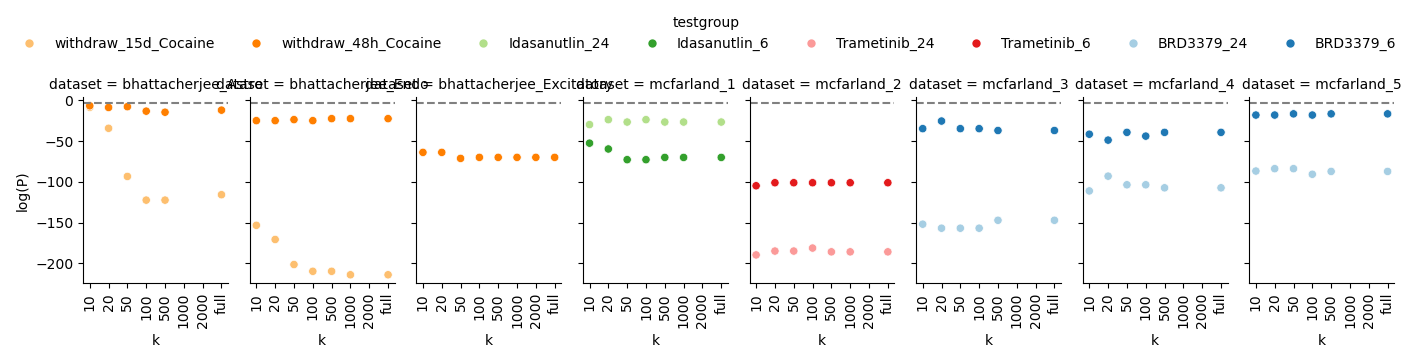

In [16]:
f = sns.relplot(df, col="dataset", hue="testgroup", x="k", y="log(P)", kind="scatter", height=3, aspect=0.5, palette=palette)
for ax in f.axes.flatten():
    ax.axhline(np.log(0.05), color="grey", ls="--")
    ax.set_xticks(ax.get_xticks(), labels=ax.get_xticklabels(), rotation=90)
sns.move_legend(f, loc="upper center", ncols=9, bbox_to_anchor=(.5, 1.2))
plt.tight_layout()
plt.savefig("../plots/supp/effect_k.svg")

In [18]:
df

,dataset,testgroup,reference,relative_support,time_test,P,k,log(P)
0,bhattacherjee_Astro,withdraw_15d_Cocaine,Maintenance_Cocaine,0.969697,5.418083,2.283189e-04,10,-8.384767
1,bhattacherjee_Astro,withdraw_48h_Cocaine,Maintenance_Cocaine,0.954733,0.256363,1.483835e-03,10,-6.513125
2,bhattacherjee_Astro,withdraw_15d_Cocaine,Maintenance_Cocaine,0.997669,0.259832,1.460281e-15,20,-34.160147
3,bhattacherjee_Astro,withdraw_48h_Cocaine,Maintenance_Cocaine,1.000000,0.282331,1.907041e-04,20,-8.564787
4,bhattacherjee_Astro,withdraw_15d_Cocaine,Maintenance_Cocaine,0.997669,0.284077,2.947057e-41,50,-93.325182
...,...,...,...,...,...,...,...,...
101,mcfarland_5,BRD3379_6,control,0.998152,0.389084,1.688979e-08,100,-17.896556
102,mcfarland_5,BRD3379_24,control,1.000000,0.670680,1.390252e-38,500,-87.168749
103,mcfarland_5,BRD3379_6,control,0.998152,0.542504,7.293297e-08,500,-16.433725
104,mcfarland_5,BRD3379_24,control,1.000000,1.539661,1.390252e-38,full,-87.168749


In [19]:
0.001

0.001

In [20]:
1.4e-03

0.0014